# CNN for comparison with the Encoder + CNN model

## Dataset preprocessing

This script performs dataset preparation and preprocessing for a binary image classification task. It splits the original dataset into training (70%), validation (15%), and test (15%) sets, organizes them into separate folders, and creates Keras `ImageDataGenerator` pipelines with data augmentation applied to the training set only.


In [ ]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Original dataset directory 
orig_dir = '/content/drive/MyDrive/binary_one_type'

# Image settings
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Train/Validation/Test split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Output directory for the split dataset
base_out_dir = '/content/drive/MyDrive/binary_one_type_split'

# Set random seed for reproducibility
np.random.seed(42)

# 1. RESET output folders to avoid duplicates
if os.path.exists(base_out_dir):
    shutil.rmtree(base_out_dir)  # Remove existing directory
for split in ['train', 'val', 'test']:
    for cls in os.listdir(orig_dir):
        os.makedirs(os.path.join(base_out_dir, split, cls), exist_ok=True)

# 2. Split the images into train/val/test
classes = [c for c in os.listdir(orig_dir) if os.path.isdir(os.path.join(orig_dir, c))]
counts = {'train': {}, 'val': {}, 'test': {}}

for cls in classes:
    img_dir = os.path.join(orig_dir, cls)
    images = [img for img in os.listdir(img_dir) if os.path.isfile(os.path.join(img_dir, img))]
    np.random.shuffle(images)  # Shuffle images before splitting

    n_total = len(images)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)
    n_test = n_total - n_train - n_val  # Ensure all images are used

    # Assign images to each split
    split_assignments = ['train'] * n_train + ['val'] * n_val + ['test'] * n_test
    for img, split in zip(images, split_assignments):
        src = os.path.join(img_dir, img)
        dst = os.path.join(base_out_dir, split, cls, img)
        shutil.copy(src, dst)  # Copy image to corresponding folder
        counts[split][cls] = counts[split].get(cls, 0) + 1  # Count per class per split

# 3. Print image distribution summary
print("Image distribution after splitting:")
for split in ['train', 'val', 'test']:
    print(f"  {split.upper()}:")
    for cls in classes:
        print(f"    {cls}: {counts[split].get(cls, 0)}")

# 4. Create Keras data generators
# Augmentation is applied only to the training set
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values
    rotation_range=10,           # Random rotation
    width_shift_range=0.1,       # Horizontal shift
    height_shift_range=0.1,      # Vertical shift
    horizontal_flip=True         # Random horizontal flipping
)
test_datagen = ImageDataGenerator(rescale=1./255)  # Only normalization for val/test

# Define paths for each split
train_dir = os.path.join(base_out_dir, 'train')
val_dir = os.path.join(base_out_dir, 'val')
test_dir = os.path.join(base_out_dir, 'test')

# Create data generators for training, validation, and testing
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Distribuzione immagini dopo la suddivisione:
  TRAIN:
    meningioma: 1246
    notumor: 1407
  VAL:
    meningioma: 267
    notumor: 301
  TEST:
    meningioma: 267
    notumor: 302
Found 2653 images belonging to 2 classes.
Found 568 images belonging to 2 classes.
Found 569 images belonging to 2 classes.


## Model Architecture Design and Implementation

Here, is defined and compiled a Convolutional Neural Network (CNN) model for binary image classification. The architecture includes three convolutional blocks, followed by a fully connected layer and a sigmoid output for binary prediction.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define a Sequential CNN model for binary classification
model = Sequential([
    # First convolutional layer with 32 filters, 3x3 kernel, ReLU activation
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    # First max pooling layer to reduce spatial dimensions
    MaxPooling2D(2, 2),

    # Second convolutional layer with 64 filters
    Conv2D(64, (3, 3), activation='relu'),
    # Second max pooling layer
    MaxPooling2D(2, 2),

    # Third convolutional layer with 128 filters
    Conv2D(128, (3, 3), activation='relu'),
    # Third max pooling layer
    MaxPooling2D(2, 2),

    # Flatten the 3D output into 1D for the fully connected layer
    Flatten(),

    # Dense (fully connected) layer with 128 neurons and ReLU activation
    Dense(128, activation='relu'),

    # Dropout layer to reduce overfitting (drop 50% of neurons randomly during training)
    Dropout(0.5),

    # Output layer with sigmoid activation for binary classification (0 or 1)
    Dense(1, activation='sigmoid')
])

# Compile the model using Adam optimizer and binary crossentropy loss function
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']  # Track accuracy during training and evaluation
)

# Print the model architecture summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',           # Monitor the validation loss
    patience=3,                   # Stop training if no improvement after 3 epochs
    restore_best_weights=True     # Restore model weights from the epoch with best validation loss
)

# Train the model using the training and validation data
history = model.fit(
    train_generator,             # Data generator for training data
    epochs=15,                   # Maximum number of epochs
    validation_data=val_generator,  # Data generator for validation data
    callbacks=[early_stop]       # Apply early stopping during training
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 41s 418ms/step - accuracy: 0.6813 - loss: 0.6043 - val_accuracy: 0.9173 - val_loss: 0.2282
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 29s 344ms/step - accuracy: 0.8954 - loss: 0.2900 - val_accuracy: 0.9173 - val_loss: 0.2129
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 337ms/step - accuracy: 0.9156 - loss: 0.2377 - val_accuracy: 0.9243 - val_loss: 0.2104
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 44s 380ms/step - accuracy: 0.9073 - loss: 0.2503 - val_accuracy: 0.8380 - val_loss: 0.3985
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 42s 392ms/step - accuracy: 0.9133 - loss: 0.2285 - val_accuracy: 0.9190 - val_loss: 0.1836
Epoch 6/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 343ms/step - accuracy: 0.9200 - loss: 0.2099 - val_accuracy: 0.8697 - val_loss: 0.2772
Epoch 7/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 342ms/step - accuracy: 0.9224 - loss: 0.2108 - val_accuracy: 0.9437 - val_loss: 0.1361
Epoch 8/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 342ms/step - accuracy: 0.9383 - loss: 0.1610 - val_accu

## Evaluation of Performance

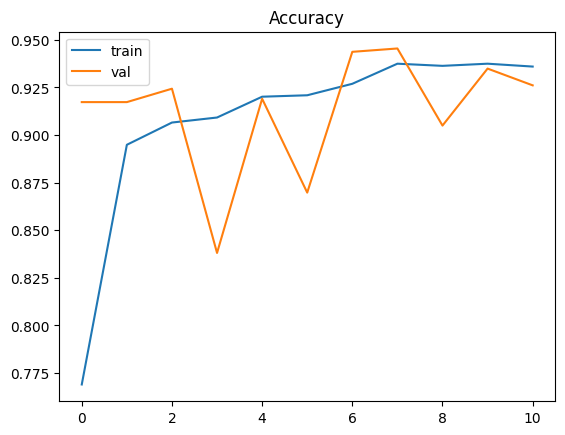

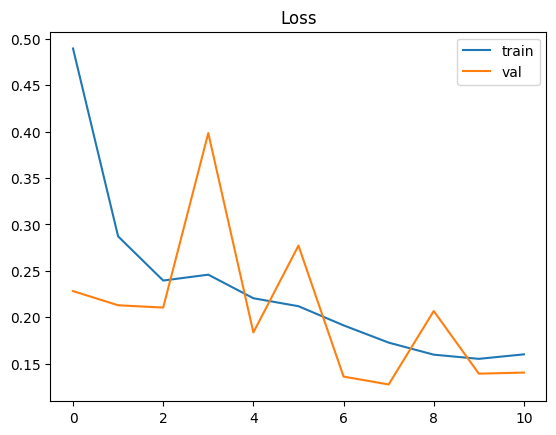

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - accuracy: 0.8927 - loss: 0.2122
Test accuracy: 0.9262
Test loss: 0.1706


In [ ]:
import matplotlib.pyplot as plt

# Performance graphs
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

# Evaluation over the Test Set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Training and validation accuracy remain consistently high, with validation accuracy peaking at around 94.5%. Loss curves for both training and validation indicate convergence, although some fluctuations in validation metrics suggest mild overfitting. On the test set, the model achieves an accuracy of **92.6%** and a loss of **0.1706**, confirming good generalization capability.


In [ ]:
import numpy as np

# --- ON THE VALIDATION SET ---

# Reset the validation generator to ensure predictions start from the beginning
val_generator.reset()

# Get prediction probabilities for each sample in the validation set
preds = model.predict(val_generator, verbose=1)

# Convert probabilities to binary class labels (0 or 1)
y_pred = (preds > 0.5).astype(int).flatten()  # Apply threshold and flatten to 1D array
y_true = val_generator.classes  # True class labels from the generator

# Print a sample of predictions vs true labels for inspection
print("Predicted:", y_pred[:10])
print("Actual:   ", y_true[:10])
print("Shape of y_pred:", y_pred.shape)
print("Shape of y_true:", y_true.shape)


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step
Predetti: [0 0 0 0 0 0 0 0 1 0]
Reali:    [0 0 0 0 0 0 0 0 0 0]
Shape y_pred: (568,)
Shape y_true: (568,)


In [ ]:
# --- PREDICTIONS ON THE TEST SET ---

# Reset the test generator to ensure predictions are made from the start
test_generator.reset()

# Get prediction probabilities for each sample in the test set
test_preds = model.predict(test_generator, verbose=1)

# Convert probabilities to binary class labels (0 or 1)
y_test_pred = (test_preds > 0.5).astype(int).flatten()  # Thresholding and flattening

# Get true class labels from the generator
y_test_true = test_generator.classes


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step


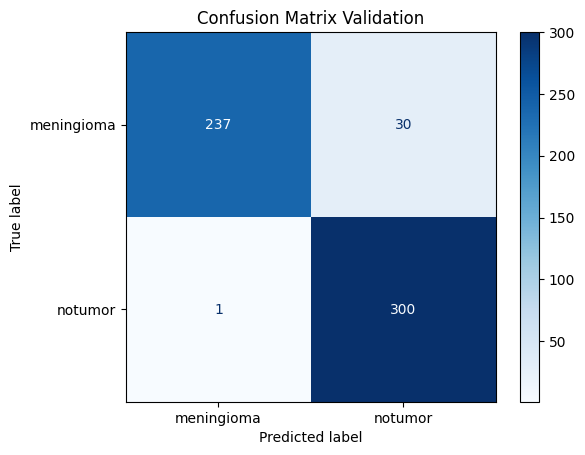

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- CONFUSION MATRIX ON VALIDATION SET ---

# Compute the confusion matrix using true and predicted labels
cm = confusion_matrix(y_true, y_pred)

# Create a ConfusionMatrixDisplay object for visualization
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_generator.class_indices.keys()  # Class names
)

# Plot the confusion matrix with a blue colormap
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Validation Set')
plt.show()

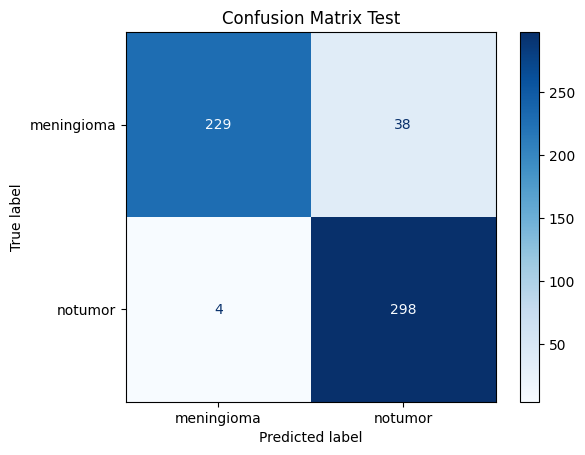

In [ ]:
# --- CONFUSION MATRIX ON TEST SET ---

# Compute the confusion matrix on the test set
cm = confusion_matrix(y_test_true, y_test_pred)

# Create display for the test set confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_generator.class_indices.keys()  # Class names
)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Test Set')
plt.show()

The validation confusion matrix shows that the model performs well, with only **30 false positives** and **1 false negative**, achieving high sensitivity and specificity. 

- **Validation:**  
  - True Positives (meningioma correctly predicted): 237  
  - True Negatives (notumor correctly predicted): 300  
  - False Positives: 30  
  - False Negatives: 1  

The test confusion matrix confirms similar performance, although with a slight increase in false positives (38 vs. 30) and false negatives (4 vs. 1). Despite this, the model generalizes well.

- **Test:**  
  - True Positives: 229  
  - True Negatives: 298  
  - False Positives: 38  
  - False Negatives: 4  

Overall, the model shows strong classification ability, especially in detecting "notumor" cases, while maintaining good recall for "meningioma".
